### ROC Curve & AUC (Receiver Operating Characteristic & Area Under Curve)
ROC Curve and AUC are evaluation metrics mainly used for **binary classification problems.**

They help answer:
> “How well can the model distinguish between positive and negative classes?”

Very important in:

- Fraud Detection
- Medical Diagnosis
- Spam Detection
- Intrusion Detection
- Risk Prediction

### Why Accuracy Is Sometimes Misleading

Suppose:
- 990 normal transactions
- 10 fraud transactions

A model predicts:
- Everything as “Normal”

Accuracy:  
$
990 / 1000 = 99%
$

Looks amazing.

But:
- It detected **0 frauds**

This is where ROC & AUC become important.

### Logistic Regression Produces Probabilities
Example:
| Sample | Probability of Positive Class |
| ------ | ----------------------------- |
| A      | 0.95                          |
| B      | 0.82                          |
| C      | 0.61                          |
| D      | 0.40                          |
| E      | 0.12                          |

Normally:
$
P(y=1) ≥ 0.5
$

Positive class

But what if we change threshold?

### Threshold Concept

Default threshold:

    0.5

But can be used:

- 0.9
- 0.7
- 0.3
- 0.1

Different thresholds produce:

- Different TP
- Different FP
- Different Recall
- Different Precision

ROC curve studies model performance across **ALL thresholds.**

### TPR and FPR

ROC curve plots:
- **TPR (True Positive Rate)** on Y-axis
- **FPR (False Positive Rate)** on X-axis

### True Positive Rate (Recall / Sensitivity)
$
TPR = TP / TP + FN
$	​

Meaning:
> Out of all actual positives, how many did model correctly detect?

### False Positive Rate
$
FPR = FP / FP + TN
$	​

Meaning:
> Out of all actual negatives, how many were wrongly predicted positive?

### ROC Curve
ROC = graph of:  

$
FPR  \ vs \  TPR
$

for different threshold values.

### Example Dataset
Suppose:
| Actual | Probability |
| ------ | ----------- |
| 1      | 0.95        |
| 1      | 0.90        |
| 1      | 0.80        |
| 0      | 0.70        |
| 0      | 0.60        |
| 0      | 0.30        |

Now evaluate at different thresholds.

##### Threshold = 0.9

Predictions:
| Prob | Prediction |
| ---- | ---------- |
| 0.95 | 1          |
| 0.90 | 1          |
| 0.80 | 0          |
| 0.70 | 0          |
| 0.60 | 0          |
| 0.30 | 0          |

Confusion matrix:
- TP = 2
- FN = 1
- FP = 0
- TN = 3

So:  

$
TPR = 2/3 = 0.67 \\
FPR = 0/3 = 0
$

ROC point:

$
(0, 0.67)
$

##### Threshold = 0.7

Predictions:
| Prob | Prediction |
| ---- | ---------- |
| 0.95 | 1          |
| 0.90 | 1          |
| 0.80 | 1          |
| 0.70 | 1          |
| 0.60 | 0          |
| 0.30 | 0          |

Confusion matrix:
- TP = 3
- FN = 0
- FP = 1
- TN = 2

So:

$
TPR = 3/3 = 1 \\
FPR = 1/3 = 0.33
$

ROC point:

$
(0.33, 1)
$

##### Threshold = 0.3
Everything positive.
- TP = 3
- FP = 3

So:

$
TPR = 1 \\
FPR = 1
$

ROC point:

$
(1, 1)
$

### Plotting ROC Curve
Points:
- (0,0)
- (0,0.67)
- (0.33,1)
- (1,1)

The better the model:
- Higher TPR
- Lower FPR

So curve should move toward:  

$
(0, 1)
$

(top-left corner)

### Perfect vs Random Model
#### Perfect Model

Reaches:

$
(0, 1)
$

Meaning:
- 100% positives detected
- 0% false alarms

#### Random Model
Diagonal line:

$
TPR = FPR
$

Equivalent to random guessing.

### AUC (Area Under Curve)

AUC = area under ROC curve.

Range:

$
0 ≤ AUC ≤ 1
$

### Interpretation of AUC
| AUC     | Meaning            |
| ------- | ------------------ |
| 1.0     | Perfect classifier |
| 0.9+    | Excellent          |
| 0.8–0.9 | Very good          |
| 0.7–0.8 | Good               |
| 0.6–0.7 | Weak               |
| 0.5     | Random guessing    |
| <0.5    | Worse than random  |

### Core Intuition of AUC
AUC measures:

Probability that model ranks a random positive sample higher than a random negative sample.

> “How often does the model put positives ahead of negatives?”

Example:

Positive score = 0.9  
Negative score = 0.4

Correct ranking.

If model consistently ranks positives above negatives:

- AUC becomes high.

### ROC Curve Shape Interpretation
#### Excellent Model

Curve hugs top-left corner.

High TPR with low FPR.

#### Poor Model

Closer to diagonal.

Cannot separate classes well.

### Advantages of ROC-AUC
#### Independent of Threshold

Evaluates across all thresholds.

#### Good for Imbalanced Data

Unlike accuracy.

#### Measures Ranking Quality

Useful when probabilities matter.

### Disadvantages
#### Can Be Misleading in Highly Imbalanced Data

Precision-Recall curve may sometimes be better.

#### Doesn't Tell Threshold

Only overall ranking ability.

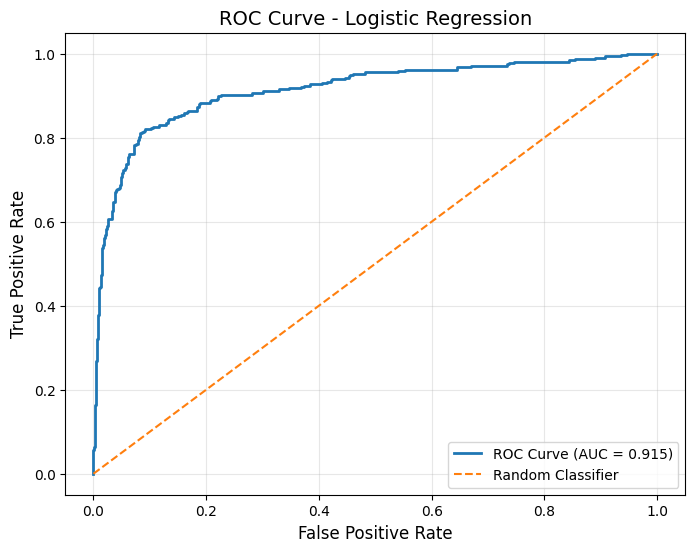

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc


# 1. Create realistic classification dataset

X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    weights=[0.7, 0.3],      # imbalanced dataset
    random_state=42
)


# 2. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 3. Train Logistic Regression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# 4. Get prediction probabilities

y_prob = model.predict_proba(X_test)[:, 1]


# 5. Compute ROC metrics

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)


# 6. Plot ROC Curve

plt.figure(figsize=(8, 6))

# ROC Curve
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

# Random classifier diagonal
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

# Formatting
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title("ROC Curve - Logistic Regression", fontsize=14)

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

```
AUC = 0.915
```
> Model has 91.5% probability of ranking a random positive sample above a random negative sample.

### ROC vs Precision-Recall Curve
| ROC                 | PR Curve                    |
| ------------------- | --------------------------- |
| Uses TPR & FPR      | Uses Precision & Recall     |
| Good overall metric | Better for severe imbalance |
| Stable              | Focuses on positive class   |

### Real-World Example
#### Cancer Detection

Lower threshold:

- Detect more cancer patients
- But more false alarms

Higher threshold:

- Fewer false alarms
- But may miss actual cancer patients

ROC helps choose appropriate tradeoff.

### Mathematical Insight

ROC traces:

$
(\mathrm{TPR}(\theta), \mathrm{FPR}(\theta))
$

for every threshold:

$
\theta \in [0,1]
$

AUC approximates:

$
\int_{0}^{1} \mathrm{TPR}(\mathrm{FPR}) \, d(\mathrm{FPR})
$

### Summary

ROC:
- Shows threshold behavior

AUC:
- Measures separability quality

Good model:
- High TPR
- Low FPR
- Large AUC

Bad model:
- Near random diagonal
- AUC ≈ 0.5

PR better for highly imbalanced datasets.